In [1]:
import dill
import json
from rich import print
from matplotlib import pyplot as plt
from matplotlib import rcParams as rc
from ipywidgets import widgets
from ipywidgets import VBox, interactive_output
import numpy as np
import pandas as pd
from simpeg.electromagnetics.utils.em1d_utils import get_vertical_discretization
from simpeg.electromagnetics.utils.em1d_utils import Stitched1DModel
from types import SimpleNamespace

rc["font.family"] = "Times New Roman"
rc["font.size"] = 14
rc["figure.figsize"] = (6, 4)
rc["axes.grid"] = True

## Workflow Overview

- Set up plotting and notebook dependencies.
- Load ATEM configuration and selected channels.
- Read and normalize the NE survey data.
- Check missing coordinate values by flight line.
- Clean missing values before binning.
- Bin each line at 50 m spacing.
- Map power-line monitor and flight height values.
- Load saved inversion outputs.
- Compare observed and predicted responses by iteration and line.
- Plot resistivity sections by iteration and line.
- Plot resistivity depth slices by iteration, line, and depth.
- Review the inversion trade-off with an L-curve.


In [2]:
istart_channel:int = 3
iend_channel:int = 25
# Load the configuration file
conf = json.load(open("../../atem/data/atem.json"))
times = np.asarray(conf['channels'])[istart_channel:iend_channel] * 1e-6
n_turns = conf['n_turns']

In [3]:
area:str = "NE"
path:str = f"../../atem/data/11-024_Alberta_{area}.csv"
dheader:list = [f"zoff30[{i}]" for i in range(istart_channel,iend_channel)]
picker:list = ["Line", "bheight", "TranPeak", "x_wgs84", "y_wgs84", "flight", 'pwrline','dtm'] + dheader # power line monitor

In [4]:
raws = pd.read_csv(path)[picker]
xy = raws[["x_wgs84", "y_wgs84"]].to_numpy()
normalizer = (-1e-9)/ (raws["TranPeak"].values * n_turns).reshape(-1, 1)
raws[[f"zoff30[{i}]" for i in range(istart_channel, iend_channel)]] = raws[[f"zoff30[{i}]" for i in range(istart_channel, iend_channel)]] * normalizer

In [5]:
line_no = list(raws["Line"].unique())

In [6]:
nan_list = raws[raws["y_wgs84"].isna()]["Line"].unique()
print(nan_list)
counts = []
for line_n in nan_list:
    count = raws[raws["Line"] == line_n]["y_wgs84"].isna().sum()
    counts.append(count)
print(counts)

<StringArray>
['L10151', 'L10460', 'L10660', 'L10700']
Length: 4, dtype: str

[65, 1, 280, 1045]

Text(0.5, 1.0, 'Line having NaN values in y_wgs84')

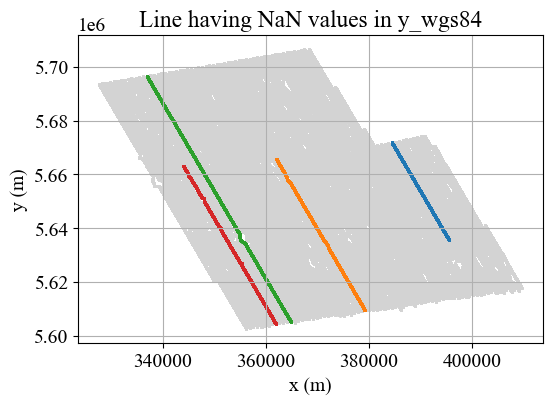

In [7]:
plt.scatter(xy[:, 0], xy[:, 1], s=1, c='lightgray', label="All data")
i=0
for line_n in nan_list:
    test_x = raws[raws["Line"] == line_n]["x_wgs84"]
    test_y = raws[raws["Line"] == line_n]["y_wgs84"]
    plt.scatter(test_x, test_y, s=1, c=f"C{i}", label=line_n)
    i += 1
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Line having NaN values in y_wgs84")

In [8]:
raws.dropna(subset=["y_wgs84"], inplace=True) # Remove rows with NaN values in y_wgs84
raws.fillna(1e-20, inplace=True) # Replace remaining NaN values with a small number (1e-20) to avoid issues in calculations

,Line,bheight,TranPeak,x_wgs84,y_wgs84,flight,pwrline,dtm,zoff30[3],zoff30[4],...,zoff30[15],zoff30[16],zoff30[17],zoff30[18],zoff30[19],zoff30[20],zoff30[21],zoff30[22],zoff30[23],zoff30[24]
0,L10040,51.911278,458.3756,402493.257158,5.641032e+06,503,-8,794.946128,-9.643729e-10,-7.876096e-10,...,-1.134681e-10,-9.594972e-11,-8.056059e-11,-6.506674e-11,-5.380087e-11,-4.421049e-11,-3.535748e-11,-2.819742e-11,-2.205398e-11,-1.766893e-11
1,L10040,51.951504,458.3796,402494.415637,5.641030e+06,503,-8,794.909939,-9.625347e-10,-7.862180e-10,...,-1.133346e-10,-9.575968e-11,-8.034887e-11,-6.487698e-11,-5.361121e-11,-4.407762e-11,-3.520288e-11,-2.806906e-11,-2.192132e-11,-1.753630e-11
2,L10040,51.990196,458.3752,402495.574117,5.641028e+06,503,-8,794.875007,-9.607055e-10,-7.848321e-10,...,-1.132120e-10,-9.559327e-11,-8.013431e-11,-6.470591e-11,-5.344875e-11,-4.394562e-11,-3.507516e-11,-2.795435e-11,-2.177165e-11,-1.737787e-11
3,L10040,52.028530,458.3842,402496.732597,5.641026e+06,503,-8,794.840569,-9.588767e-10,-7.834475e-10,...,-1.131146e-10,-9.543072e-11,-7.991971e-11,-6.454396e-11,-5.331321e-11,-4.384081e-11,-3.497925e-11,-2.784985e-11,-2.162800e-11,-1.722122e-11
4,L10040,52.065350,458.3826,402497.891079,5.641024e+06,503,-8,794.807567,-9.570899e-10,-7.820963e-10,...,-1.130134e-10,-9.526399e-11,-7.971802e-11,-6.438149e-11,-5.318124e-11,-4.374807e-11,-3.491266e-11,-2.776143e-11,-2.149592e-11,-1.705858e-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2468249,L10795,47.950359,460.7822,350092.607768,5.620167e+06,537,-14,976.952278,-5.277656e-10,-4.259794e-10,...,-5.095371e-11,-4.073690e-11,-3.314252e-11,-2.727702e-11,-2.102542e-11,-1.627180e-11,-1.283453e-11,-1.178583e-11,-1.098103e-11,-9.639738e-12
2468250,L10795,48.262875,460.7836,350094.300742,5.620164e+06,537,-14,976.924965,-5.240232e-10,-4.230274e-10,...,-5.057818e-11,-4.056675e-11,-3.306444e-11,-2.703948e-11,-2.084331e-11,-1.615130e-11,-1.266985e-11,-1.156742e-11,-1.080611e-11,-9.521045e-12
2468251,L10795,48.575470,460.7808,350095.995313,5.620162e+06,537,-14,976.898144,-5.201460e-10,-4.199702e-10,...,-5.014192e-11,-4.030966e-11,-3.291694e-11,-2.677578e-11,-2.065676e-11,-1.597851e-11,-1.246160e-11,-1.133130e-11,-1.056570e-11,-9.328209e-12
2468252,L10795,48.888226,460.7936,350097.689886,5.620159e+06,537,-14,976.872093,-5.162822e-10,-4.169470e-10,...,-4.974798e-11,-4.008213e-11,-3.278211e-11,-2.654657e-11,-2.050933e-11,-1.579721e-11,-1.227103e-11,-1.110839e-11,-1.026474e-11,-9.100929e-12


In [9]:
dx = 50.
values = []
values_std = []
soundings = []
istart = 0
iend = len(line_no)

for i_line, line in enumerate(line_no[istart:iend]):
    df_line = raws[raws['Line']==line]

    # Calculate distance along the "Line"
    xy = df_line[["x_wgs84", "y_wgs84"]].to_numpy()
    distance = np.sqrt(((xy-xy[0,:])**2).sum(axis=1))
    # print(f"Number of NaN values in distance: {np.isnan(distance).sum()}")
    max_distance = distance.max()

    # Determine the no. of soundings per bin.
    if max_distance % dx ==0:
        n_sounding = int(max_distance / dx)
    else:
        n_sounding = int(np.round(max_distance / dx) + 1)

    # Create bins and assign each sounding to a bin
    bins = np.arange(n_sounding) * dx
    df_line.insert(0, 'distance', distance)
    # Bin distances
    df_line['bin'] = pd.cut(df_line['distance'], bins=bins)
    # Compute statistics per bin
    binned = (
        df_line.groupby('bin', observed=False)
            [['distance'] + picker[1:]]
            .mean()
    )
    binned.insert(0, 'Line', line)
    binned_std = (
        df_line.groupby('bin', observed=False)
            [['bheight'] + dheader]
            .std()
    )
    values.append(binned.values)
    values_std.append(binned_std.values)
    soundings.append(n_sounding)

df_data_binned = pd.DataFrame(data=np.vstack(values), columns=['Line', 'distance'] + picker[1:])
df_data_std_binned = pd.DataFrame(data=np.vstack(values_std), columns=['bheight'] + dheader)

# Store distance information for each line
distance_by_line = {}
for i_line, line in enumerate(line_no):
    line_start_idx = sum(soundings[:i_line])
    line_end_idx = line_start_idx + soundings[i_line]
    distance_by_line[line] = df_data_binned.iloc[line_start_idx:line_end_idx]['distance'].values

## Flight-Line Monitor Maps

Map the power-line monitor and flight height values in x-y space.


Text(0.5, 1.0, 'Flight Height')

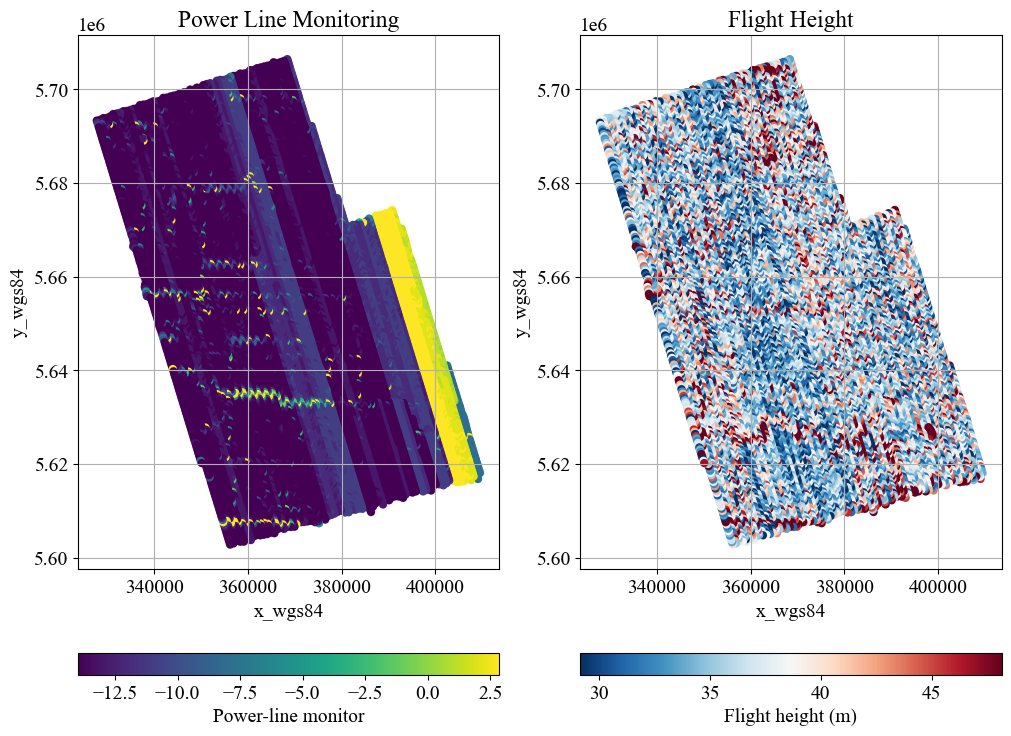

In [10]:
monitor_skip = 10
monitor_index = np.arange(0, len(df_data_binned), monitor_skip)

fig, axs = plt.subplots(1, 2, figsize=(10, 8), constrained_layout=True)
ax1, ax2 = axs

pwrline_values = df_data_binned['pwrline'].values.astype(float)
bheight_values = df_data_binned['bheight'].values.astype(float)
x_values = df_data_binned['x_wgs84'].values.astype(float)
y_values = df_data_binned['y_wgs84'].values.astype(float)

out1 = ax1.scatter(
    x_values[monitor_index],
    y_values[monitor_index],
    c=pwrline_values[monitor_index],
    # s=1,
    vmin=np.nanpercentile(pwrline_values[monitor_index], 5),
    vmax=np.nanpercentile(pwrline_values[monitor_index], 95),
    edgecolors='none',
)
cb1 = plt.colorbar(out1, ax=ax1, orientation='horizontal', fraction=0.05, pad=0.05)
cb1.set_label('Power-line monitor')
ax1.set_aspect(1)
ax1.set_xlabel('x_wgs84')
ax1.set_ylabel('y_wgs84')
ax1.set_title('Power Line Monitoring')

out2 = ax2.scatter(
    x_values[monitor_index],
    y_values[monitor_index],
    c=bheight_values[monitor_index],
    # s=1,
    vmin=np.nanpercentile(bheight_values[monitor_index], 5),
    vmax=np.nanpercentile(bheight_values[monitor_index], 95),
    cmap='RdBu_r',
    edgecolors='none',
)
cb2 = plt.colorbar(out2, ax=ax2, orientation='horizontal', fraction=0.05, pad=0.05)
cb2.set_label('Flight height (m)')
ax2.set_aspect(1)
ax2.set_xlabel('x_wgs84')
ax2.set_ylabel('y_wgs84')
ax2.set_title('Flight Height')


In [11]:
n_time = len(times)
dobs = df_data_binned[dheader].values.flatten() # Binned Data

In [12]:
with open("../data/worst_50_smoothed_rmse.json", "r") as f:
    worst_50_line = json.load(f)[0]
f.close()

In [13]:
worst_50_line.values()

dict_values(['L10240', 'L10320', 'L10602', 'L10721', 'L10781', 'L10701', 'L10361', 'L10090', 'L10660', 'L10600', 'L10520', 'L10140', 'L10250', 'L10072', 'L10650', 'L10730', 'L10181', 'L10683', 'L10700', 'L10251', 'L10672', 'L10620', 'L10060', 'L10720', 'L10682', 'L10210', 'L10221', 'L10201', 'L10200', 'L10272', 'L10461', 'L10070', 'L10150', 'L10192', 'L10360', 'L10040', 'L10130', 'L10551', 'L10581', 'L10390', 'L10795', 'L10552', 'L10651', 'L10510', 'L10281', 'L10750', 'L10231', 'L10671', 'L10081', 'L10710'])

In [14]:
# name:str = "../data/inv_results_atem_full.pik"
name:str = "../data/inv_results_atem_full_2.pik"
outDict:dict = dill.load(open(name, "rb"))
print(outDict.keys())

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])

In [15]:
print(outDict[1])

{
    'iter': 1,
    'beta': 23146.380462973044,
    'phi_d': 356874021.6910515,
    'phi_m': 2316.064300101717,
    'f': 1293247462.232524,
    'm': array([-2.72237593, -2.71505586, -2.70090626, ..., -2.34954963,
       -2.34791945, -2.34720297]),
    'dpred': array([-1.14656407e-09, -9.20582269e-10, -7.12436856e-10, ...,
       -3.68358470e-11, -3.05051634e-11, -2.51477630e-11]),
    'SparseSmallness.irls_threshold': 1e-08,
    'SparseSmallness.norm': 1,
    'r LaterallyConstrainedSmoothness.irls_threshold': 1e-08,
    'r LaterallyConstrainedSmoothness.norm': 1,
    'z LaterallyConstrainedSmoothness.irls_threshold': 1e-08,
    'z LaterallyConstrainedSmoothness.norm': 1
}

In [16]:
iterations = len(outDict.keys())
print(f"{iterations=}")

iterations=20

In [17]:

topography = df_data_binned[['x_wgs84','y_wgs84', 'dtm']].values
source_heights = df_data_binned['bheight'].values
thickness = get_vertical_discretization(21, 2, 1.17)

>> Depth from the surface to the base of the bottom layer is 306.3m


In [18]:

input_data_dict = {
    "topography": topography.astype(float),
    "source_heights": source_heights.astype(float),
    "thickness": thickness,
    "times":times,    
}
inp = SimpleNamespace(**input_data_dict)

In [19]:
line = np.array([int(str(val).strip('L').strip('T')) for val in df_data_binned['Line'].values])
unique_line_values = np.unique(line)
line_name_values = [str(val) for val in line_no]

n_sounding = len(line)

In [20]:
m = outDict[1]['m']

## Depth slice map

- Plot the inverted resistivity model at a selected depth layer in `x_wgs84` / `y_wgs84` coordinates.
- And compare the difference between each iteration.


In [21]:
from scipy.spatial import cKDTree as KDTree
from matplotlib.colors import LogNorm

# Grid and interpolation settings for resistivity depth-slice maps.
map_dx = 100.0
map_dy = 100.0
x_pad = 1000.0
y_pad = 1000.0
k_nearest_points = 100
max_distance = 500.0
idw_power = 0.0

xy_model = inp.topography[:, :2]
xmin, xmax = xy_model[:, 0].min() - x_pad, xy_model[:, 0].max() + x_pad
ymin, ymax = xy_model[:, 1].min() - y_pad, xy_model[:, 1].max() + y_pad

nx = int((xmax - xmin) / map_dx)
ny = int((ymax - ymin) / map_dy)
x_map = np.arange(nx) * map_dx + xmin
y_map = np.arange(ny) * map_dy + ymin
X_map, Y_map = np.meshgrid(x_map, y_map)

map_tree = KDTree(xy_model)
distances_idw, indices_idw = map_tree.query(
    np.c_[X_map.ravel(), Y_map.ravel()],
    k=int(k_nearest_points),
)

idw_epsilon = min(map_dx, map_dy)
idw_weights = 1.0 / ((distances_idw + idw_epsilon) ** idw_power)
nearest_distance, _ = map_tree.query(np.c_[X_map.ravel(), Y_map.ravel()], k=1)
mask_outside_data = nearest_distance > max_distance

hz = np.r_[thickness, thickness[-1]]
depth_edges = np.r_[0.0, np.cumsum(hz)]
depth_centers = 0.5 * (depth_edges[:-1] + depth_edges[1:])
n_layer = len(hz)


In [22]:
def plot_combined_map_and_line(i_iteration, line_name, i_depth):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
    
    # --- Left: Depth Slice Map ---
    m_iter = np.asarray(outDict[i_iteration]['m'])
    rho_iter = 1.0 / np.exp(m_iter)
    rho_layers = rho_iter.reshape((n_sounding, n_layer))

    values = rho_layers[:, i_depth]
    values_grid = np.sum(idw_weights * values[indices_idw], axis=1) / np.sum(idw_weights, axis=1)
    # values_grid = values[indices_idw]
    values_grid[mask_outside_data] = np.nan
    values_grid = values_grid.reshape(X_map.shape)

    selected_line = df_data_binned[df_data_binned['Line'].astype(str) == str(line_name)]
    if selected_line.empty:
        raise ValueError(f"No data found for line {line_name}")

    out = ax1.pcolormesh(
        x_map,
        y_map,
        values_grid,
        cmap='turbo',
        norm=LogNorm(vmin=8, vmax=60),
        shading='auto',
    )
    ax1.plot(xy_model[:, 0], xy_model[:, 1], 'k,', alpha=0.12)
    ax1.plot(
        selected_line['x_wgs84'],
        selected_line['y_wgs84'],
        color='white',
        linewidth=2.0,
    )
    ax1.plot(
        selected_line['x_wgs84'],
        selected_line['y_wgs84'],
        color='black',
        linewidth=0.8,
    )
    ax1.scatter(
        selected_line['x_wgs84'].iloc[0],
        selected_line['y_wgs84'].iloc[0],
        s=30,
        color='white',
        edgecolor='black',
        zorder=5,
    )

    cb = plt.colorbar(out, ax=ax1, orientation='vertical')
    cb.set_label('Resistivity (ohm-m)')
    ax1.set_xlabel('x_wgs84')
    ax1.set_ylabel('y_wgs84')
    ax1.set_aspect(1)
    ax1.set_title(
        f"Iteration {i_iteration}, Line {line_name}, "
        f"Depth {depth_centers[i_depth]:.1f} m"
    )
    ax1.grid(True, alpha=0.15)
    
    # --- Right: Data Line Plot ---
    i_line_num = line_no.index(line_name)
    
    line_start_idx = sum(soundings[:i_line_num])
    n_soundings_in_line = soundings[i_line_num]
    
    DPRED = outDict[i_iteration]['dpred'].reshape((-1, n_time))
    DOBS = dobs.reshape((-1, n_time))
    
    distances = distance_by_line[line_name]
    
    sort_idx = np.argsort(distances)
    distances_sorted = distances[sort_idx]
    
    for i_time in range(n_time):
        dpred_line = -DPRED[line_start_idx:line_start_idx + n_soundings_in_line, i_time]
        dobs_line = -DOBS[line_start_idx:line_start_idx + n_soundings_in_line, i_time]
        
        dpred_sorted = dpred_line[sort_idx]
        dobs_sorted = dobs_line[sort_idx]
        
        ax2.plot(distances_sorted, dpred_sorted, '-', linewidth=1.5, alpha=0.7, label=f'T{i_time}')
        ax2.plot(distances_sorted, dobs_sorted, 'k--', linewidth=1, alpha=0.5)
    
    ax2.set_yscale('log')
    ax2.set_xlabel('Distance along line (m)')
    ax2.set_ylabel('|dB/dt| (V/A/m²)')
    ax2.legend(ncol=2, fontsize=8)
    ax2.grid(False)
    ax2.set_title(f"Iteration {i_iteration}, Line {line_name}")
    
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

iter_depth_slider = widgets.IntSlider(
    min=1,
    max=iterations,
    step=1,
    value=1,
    description='Iteration:',
    continuous_update=False,
)
line_slider = widgets.SelectionSlider(
    options=line_name_values,
    value=line_name_values[0],
    description='Line:',
)
depth_slider = widgets.SelectionSlider(
    options=[(f"{i}: {depth_centers[i]:.1f} m", i) for i in range(n_layer)],
    value=0,
    description='Depth:',
    continuous_update=False,
)

combined_output = interactive_output(
    plot_combined_map_and_line,
    {
        'i_iteration': iter_depth_slider,
        'line_name': line_slider,
        'i_depth': depth_slider,
    },
)

VBox([iter_depth_slider, line_slider, depth_slider, combined_output])


In [23]:
def min_max_scaler(arr):
    min_val = np.min(arr)
    max_val = np.max(arr)
    if max_val - min_val == 0:
        return np.zeros_like(arr)  # Avoid division by zero, return zeros if all values are the same
    scaled_arr = (arr - min_val) / (max_val - min_val)
    return scaled_arr


In [24]:
def compute_line_directional_ratios_by_depth(i_iteration, opt="C1"):
    rho_iter = 1.0 / np.exp(outDict[i_iteration - 1]["m"])
    rho_next = 1.0 / np.exp(outDict[i_iteration]["m"])
    rho_layers_iter = rho_iter.reshape((n_sounding, n_layer))
    rho_layers_next = rho_next.reshape((n_sounding, n_layer))

    # Basis vector: First line (soundings[0]) direction is used.
    first_line_xy = xy_model[:soundings[0]]
    first_line_vec = first_line_xy[-1] - first_line_xy[0]
    first_line_angle = np.arctan2(first_line_vec[1], first_line_vec[0])
    along_u = np.array([np.cos(first_line_angle), np.sin(first_line_angle)])
    perp_u = np.array([-np.sin(first_line_angle), np.cos(first_line_angle)])

    depth_ratios = []
    for i_depth in range(n_layer):
        values_iter = rho_layers_iter[:, i_depth]
        values_next = rho_layers_next[:, i_depth]
        values_diff = values_next - values_iter

        values_diff_grid = np.sum(idw_weights * values_diff[indices_idw], axis=1) / np.sum(idw_weights, axis=1)
        # values_diff_grid = values_diff[indices_idw]
        values_diff_grid[mask_outside_data] = np.nan
        values_diff_grid = values_diff_grid.reshape(X_map.shape)

        dy_grid, dx_grid = np.gradient(values_diff_grid, y_map, x_map)

        if opt =="C1":
            along_proj = np.nanmean(np.abs(dx_grid * along_u[0] + dy_grid * along_u[1]))
            perp_proj = np.nanmean(np.abs(dx_grid * perp_u[0] + dy_grid * perp_u[1]))
            depth_ratios.append(perp_proj / along_proj)

        if opt =="C2":
            # L2-norm of projections onto along and perpendicular directions
            along_proj = np.sqrt(np.nanmean((dx_grid * along_u[0] + dy_grid * along_u[1])**2))
            perp_proj = np.sqrt(np.nanmean((dx_grid * perp_u[0] + dy_grid * perp_u[1])**2))
            depth_ratios.append(perp_proj / along_proj)

        if opt == "C3":
            along_proj = dx_grid * along_u[0] + dy_grid * along_u[1]
            perp_proj = dx_grid * perp_u[0] + dy_grid * perp_u[1]
            along_proj[along_proj <= 1e-10] = np.inf
            ratio = np.nanmean(np.abs(perp_proj / along_proj))
            depth_ratios.append(ratio)

        if opt == "C4":
            along_proj = dx_grid * along_u[0] + dy_grid * along_u[1]
            perp_proj = dx_grid * perp_u[0] + dy_grid * perp_u[1]
            along_proj[along_proj <= 1e-10] = np.inf
            ratio = np.sqrt(np.nanmean((perp_proj / along_proj)**2))
            depth_ratios.append(ratio)
        
        if opt == "C5":
            along_proj = dx_grid * along_u[0] + dy_grid * along_u[1]
            perp_proj = dx_grid * perp_u[0] + dy_grid * perp_u[1]
            depth_ratios.append(
                np.nanmean(
                    ( - (along_proj)**2 + (perp_proj)**2)/((along_proj)**2 + (perp_proj)**2 + 1e-10)
                )
            )


    return np.array(depth_ratios)


In [25]:
# Precompute ratio matrix across iterations (1..iterations-1) and depths
ratio_matrix_L2 = np.vstack([compute_line_directional_ratios_by_depth(i, opt="C2") for i in range(2, iterations + 1)])
ratio_matrix_L1 = np.vstack([compute_line_directional_ratios_by_depth(i, opt="C1") for i in range(2, iterations + 1)])

In [26]:
ratio_matrix_S2 = np.vstack([compute_line_directional_ratios_by_depth(i, opt="C4") for i in range(2, iterations + 1)])
ratio_matrix_S1 = np.vstack([compute_line_directional_ratios_by_depth(i, opt="C3") for i in range(2, iterations + 1)])

In [27]:
ratio_matrix_A = np.vstack([compute_line_directional_ratios_by_depth(i, opt="C5") for i in range(2, iterations + 1)])

In [28]:
def plot_ratio_by_depth(depth_index=0):
    iters = np.arange(2, iterations + 1)
    ratio_values = ratio_matrix_A[:, depth_index]

    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    ax.plot(iters, ratio_values, marker='o', color='tab:blue', linewidth=2.5, markersize=8)
    ax.set_xlabel('Iteration', fontsize=12, fontweight='bold')
    ax.set_ylabel('Perp/Along Ratio', fontsize=12, fontweight='bold')
    ax.set_title(f'Depth {depth_centers[depth_index]:.1f} m: Perp/Along Ratio by Iteration', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(np.nanmin(ratio_values)*1.1, np.nanmax(ratio_values) * 1.1)
    plt.show()

depth_slider = widgets.SelectionSlider(
    options=[(f"{i}: {depth_centers[i]:.1f} m", i) for i in range(n_layer)],
    value=0,
    description='Depth:',
    continuous_update=False,
)

ratio_output = interactive_output(
    plot_ratio_by_depth,
    {'depth_index': depth_slider},
)

VBox([depth_slider, ratio_output])


In [29]:
def plot_iteration_resistivity_comparison(i_iteration, i_depth):
    """Plot resistivity maps for iteration i, i+1, and their difference."""
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # Get resistivity for both iterations
    rho_iter = 1.0 / np.exp(outDict[i_iteration - 1]["m"])
    rho_next = 1.0 / np.exp(outDict[i_iteration]["m"])
    
    rho_layers_iter = rho_iter.reshape((n_sounding, n_layer))
    rho_layers_next = rho_next.reshape((n_sounding, n_layer))
    
    values_iter = rho_layers_iter[:, i_depth]
    values_next = rho_layers_next[:, i_depth]
    values_diff = values_next - values_iter
    
    # Interpolate to grid
    values_iter_grid = np.sum(idw_weights * values_iter[indices_idw], axis=1) / np.sum(idw_weights, axis=1)
    # values_iter_grid = values_iter[indices_idw]
    values_iter_grid[mask_outside_data] = np.nan
    values_iter_grid = values_iter_grid.reshape(X_map.shape)
    
    values_next_grid = np.sum(idw_weights * values_next[indices_idw], axis=1) / np.sum(idw_weights, axis=1)
    # values_next_grid = values_next[indices_idw]
    values_next_grid[mask_outside_data] = np.nan
    values_next_grid = values_next_grid.reshape(X_map.shape)
    
    values_diff_grid = np.sum(idw_weights * values_diff[indices_idw], axis=1) / np.sum(idw_weights, axis=1)
    # values_diff_grid = values_diff[indices_idw]
    values_diff_grid[mask_outside_data] = np.nan
    values_diff_grid = values_diff_grid.reshape(X_map.shape)
    
    # Plot iteration i
    out1 = ax1.pcolormesh(x_map, y_map, values_iter_grid, cmap="turbo", norm=LogNorm(vmin=8, vmax=60), shading="auto")
    ax1.plot(xy_model[:, 0], xy_model[:, 1], "k,", alpha=0.12)
    ax1.set_aspect(1)
    ax1.set_title(f"Iteration {i_iteration - 1}, Depth {depth_centers[i_depth]:.1f} m")
    ax1.set_xlabel("x_wgs84")
    ax1.set_ylabel("y_wgs84")
    plt.colorbar(out1, ax=ax1, label="Resistivity (Ω·m)")
    
    # Plot iteration i+1
    out2 = ax2.pcolormesh(x_map, y_map, values_next_grid, cmap="turbo", norm=LogNorm(vmin=8, vmax=60), shading="auto")
    ax2.plot(xy_model[:, 0], xy_model[:, 1], "k,", alpha=0.12)
    ax2.set_aspect(1)
    ax2.set_title(f"Iteration {i_iteration}, Depth {depth_centers[i_depth]:.1f} m")
    ax2.set_xlabel("x_wgs84")
    ax2.set_ylabel("y_wgs84")
    plt.colorbar(out2, ax=ax2, label="Resistivity (Ω·m)")
    
    # Plot difference
    vmax_diff = np.nanmax(np.abs(values_diff_grid))
    out3 = ax3.pcolormesh(x_map, y_map, values_diff_grid, cmap="RdBu_r", vmin=-vmax_diff, vmax=vmax_diff, shading="auto")
    ax3.plot(xy_model[:, 0], xy_model[:, 1], "k,", alpha=0.12)
    ax3.set_aspect(1)
    ax3.set_title(f"Difference (Iter {i_iteration} - Iter {i_iteration - 1})")
    ax3.set_xlabel("x_wgs84")
    ax3.set_ylabel("y_wgs84")
    plt.colorbar(out3, ax=ax3, label="ΔResistivity (Ω·m)")
    # plt.colorbar(out3, ax=ax3, label="Normalized ΔResistivity (Ω·m)")
    
    plt.tight_layout()
    plt.show()

iter_slider = widgets.IntSlider(
    min=2,
    max=iterations,
    step=1,
    value=2,
    description="Iteration:",
    continuous_update=False,
)

iter_depth_slider_comp = widgets.SelectionSlider(
    options=[(f"{i}: {depth_centers[i]:.1f} m", i) for i in range(n_layer)],
    value=0,
    description="Depth:",
    continuous_update=False,
)

iter_comparison_output = interactive_output(
    plot_iteration_resistivity_comparison,
    {"i_iteration": iter_slider, "i_depth": iter_depth_slider_comp},
)

VBox([iter_slider, iter_depth_slider_comp, iter_comparison_output])


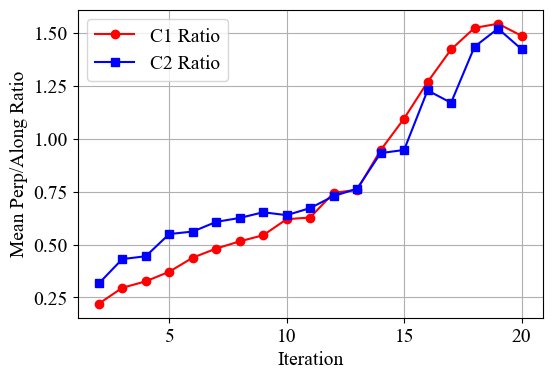

In [30]:
plt.plot([it for it in range(2, iterations + 1)], (np.mean(ratio_matrix_L1, axis=1)), c='red', marker='o')
plt.plot([it for it in range(2, iterations + 1)], (np.mean(ratio_matrix_L2, axis=1)), c='blue', marker='s')
# plt.plot([it for it in range(2, iterations + 1)], (np.mean(ratio_matrix_S1, axis=1)), c='black', marker='x')
# plt.plot([it for it in range(2, iterations + 1)], (np.mean(ratio_matrix_S2, axis=1)), c='gray', marker='h')
# plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Mean Perp/Along Ratio')
plt.legend(['C1 Ratio', 'C2 Ratio', 'C3 Ratio', 'C4 Ratio' ])

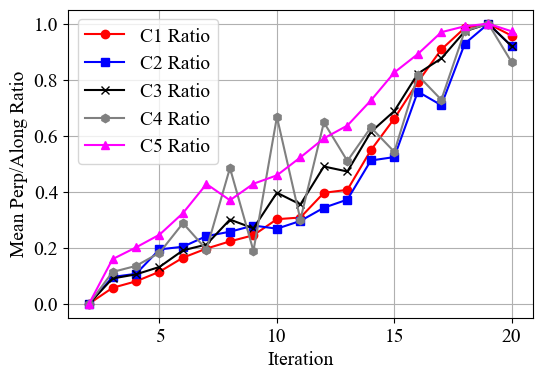

In [32]:
plt.plot([it for it in range(2, iterations + 1)], min_max_scaler(np.mean(ratio_matrix_L1, axis=1)), c='red', marker='o')
plt.plot([it for it in range(2, iterations + 1)], min_max_scaler(np.mean(ratio_matrix_L2, axis=1)), c='blue', marker='s')
plt.plot([it for it in range(2, iterations + 1)], min_max_scaler(np.mean(ratio_matrix_S1, axis=1)), c='black', marker='x')
plt.plot([it for it in range(2, iterations + 1)], min_max_scaler(np.mean(ratio_matrix_S2, axis=1)), c='gray', marker='h')
plt.plot([it for it in range(2, iterations + 1)], min_max_scaler(np.mean(ratio_matrix_A, axis=1)), c='magenta', marker='^')
# plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Mean Perp/Along Ratio')
plt.legend(['C1 Ratio', 'C2 Ratio', 'C3 Ratio', 'C4 Ratio', 'C5 Ratio'])